In [1]:
import pickle

In [2]:
# Load dataset
# with open('C:/Users/101194208/Desktop/Die-Cast Ensemble/Data/auc_cnn.pkl', 'rb') as file:
#     auc_cnn = pickle.load(file)
# with open('C:/Users/101194208/Desktop/Die-Cast Ensemble/Data/auc_resnet.pkl', 'rb') as file:
#     auc_resnet = pickle.load(file)
# with open('C:/Users/101194208/Desktop/Die-Cast Ensemble/Data/auc_vit.pkl', 'rb') as file:
#     auc_vit = pickle.load(file)

with open('C:/Users/101194208/Desktop/Die-Cast Ensemble/Data/cnn.pkl', 'rb') as file:
    loaded_data = pickle.load(file)
cnn_prob, cnn_auc, cnn_fpr, cnn_tpr = loaded_data['var1'], loaded_data['var2'], loaded_data['var3'], loaded_data['var4']

with open('C:/Users/101194208/Desktop/Die-Cast Ensemble/Data/resnet.pkl', 'rb') as file:
    loaded_data = pickle.load(file)
res_prob, res_auc, res_fpr, res_tpr = loaded_data['var1'], loaded_data['var2'], loaded_data['var3'], loaded_data['var4']

with open('C:/Users/101194208/Desktop/Die-Cast Ensemble/Data/vit.pkl', 'rb') as file:
    loaded_data = pickle.load(file)
vit_prob, vit_auc, vit_fpr, vit_tpr = loaded_data['var1'], loaded_data['var2'], loaded_data['var3'], loaded_data['var4']

with open('C:/Users/101194208/Desktop/Die-Cast Ensemble/Data/y_onehot_test.pkl', 'rb') as file:
    y_onehot_test = pickle.load(file)

In [3]:
num_runs = 10 # 10 replicate runs of training, testing

# Box Plot

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
def box(cnn_auc, res_auc, vit_auc, type='micro', n=num_runs):
    """
    Generate dataframe containing AUC information of three models for 10 runs.
    Plot the boxplot of AUC by models.

    Args:
        type (string): The type of AUC. ['micro', 0, 1, 2, 'macro']
        n (int): The number of replicate runs of training and testing.

    Returns:
        plot: The boxplot of AUC by models.
    """
    df = pd.DataFrame(columns=['model', 'auc']) # 1. Create an empty DataFrame with specified columns
    for i in range(n): # 2. Iterate and append rows # CNN
        row_data = ['CNN', float(cnn_auc[i][type])]
        df.loc[len(df)] = row_data
    for i in range(n): # ResNet
        row_data = ['ResNet', float(res_auc[i][type])]
        df.loc[len(df)] = row_data
    for i in range(n): # ViT
        row_data = ['ViT', float(vit_auc[i][type])]
        df.loc[len(df)] = row_data
    df = df.reset_index(drop=True) # 3. Reset the index (optional)

    if type == 'mirco':
        s = 'Micro-Average'
    elif type == 0:
        s = 'Flawless'
    elif type == 1:
        s = 'Crack'
    elif type == 2:
        s = 'Cold Flow'
    else:
        s = 'Macro-Average'
    plt.figure(figsize=(8, 6)) # Optional: set figure size
    sns.boxplot(x='model', y='auc', data=df) # hue='Subgroup'
    # plt.ylim(0.9, 1.0)
    plt.title('Box Plot of AUC(' + s +  ') by Model') # and Subgroup
    plt.xlabel('Models')
    plt.ylabel('AUC')
    # plt.legend(title='Subgroup')
    plt.grid(axis='y', linestyle='--', alpha=0.7) # Optional: add a grid
    plt.savefig("C:/Users/101194208/Desktop/Die-Cast Ensemble/Results Plots/box_" + str(type)+ ".png", bbox_inches="tight", dpi=300)
    plt.show()

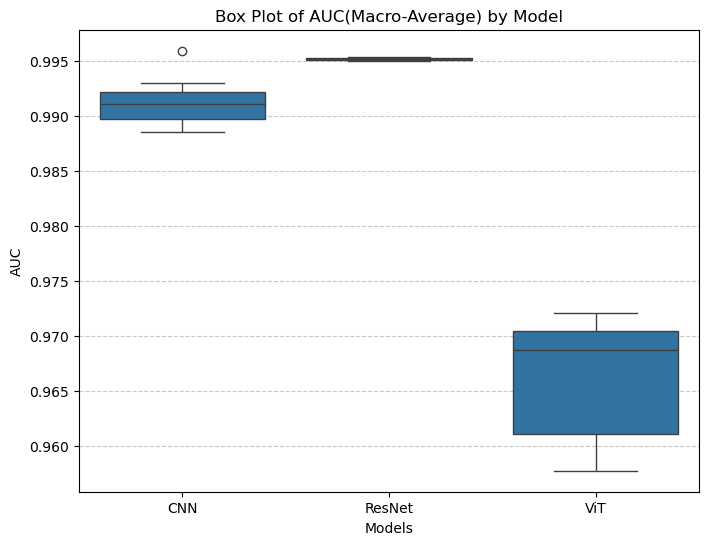

In [8]:
# Micro-Average AUC
box(cnn_auc, res_auc, vit_auc, type='micro', n=num_runs)

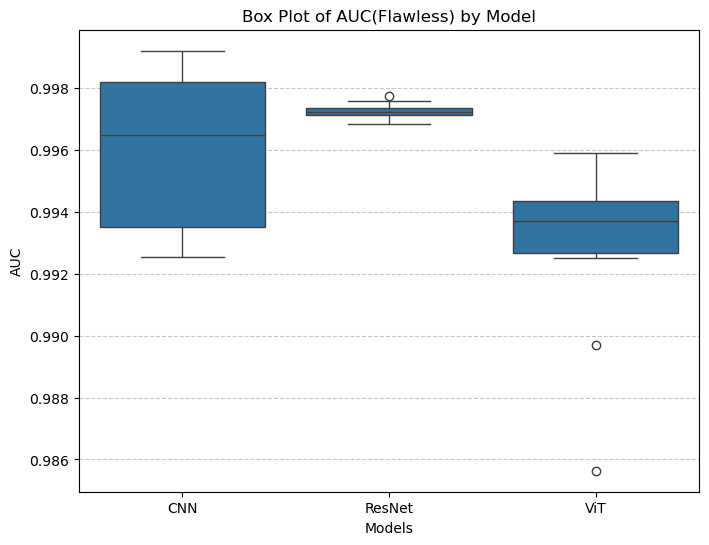

In [9]:
# One-vs-Rest Flawless AUC
box(cnn_auc, res_auc, vit_auc, type=0, n=num_runs)

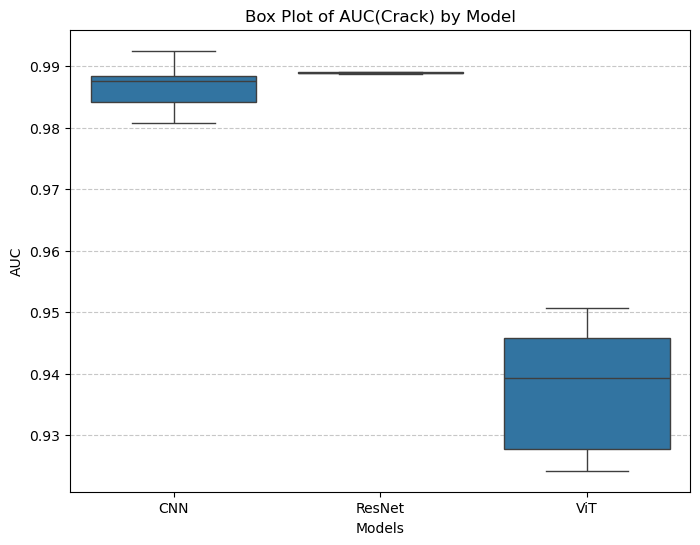

In [10]:
# One-vs-Rest Crack AUC
box(cnn_auc, res_auc, vit_auc, type=1, n=num_runs)

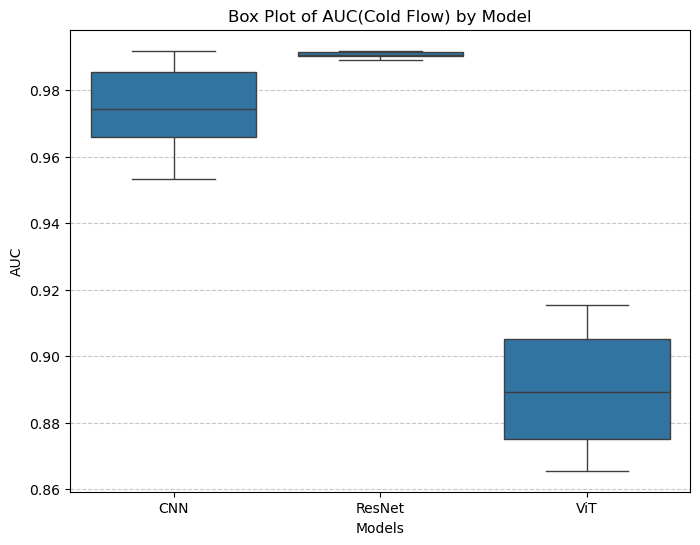

In [11]:
# One-vs-Rest Cold Flow AUC
box(cnn_auc, res_auc, vit_auc, type=2, n=num_runs)

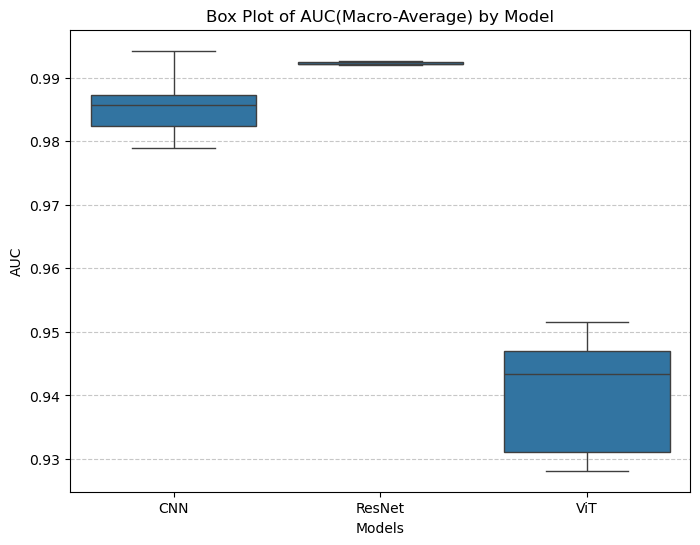

In [12]:
# Macro-Average AUC
box(cnn_auc, res_auc, vit_auc, type='macro', n=num_runs)

# Best AUC Index for Each Model

In [ ]:
import numpy as np

In [ ]:
def best_auc(data): # Figure out which run has the best AUC for each model
    keys = ['micro', 0, 1, 2, 'macro'] # a list of all the metrics we want to check

    # Dictionary Comprehension: {k: something for k in keys} - For each key in keys, compute something, and store it in a dictionary where k is the key.
    # max(..., key=lambda i: data[i][k]): The max() function finds the element of the iterable (range(len(data))) that gives the largest value 
    # when evaluated by the key function.
    best_indices = {k: max(range(len(data)), key=lambda i: data[i][k]) for k in keys} # loops over all indices, comparing each value for key k.
    best_values = {k: data[best_indices[k]][k] for k in keys}
    
    print("Best indices:", best_indices)
    print("Best values:", best_values)

In [ ]:
best_auc(cnn_auc)

In [ ]:
best_auc(res_auc)

In [ ]:
best_auc(vit_auc)

In [ ]:
data_list = [['CNN', 2, 6, 2, 2, 2],
             ['ResNet', 6, 0, 6, 9, 2],
             ['ViT', 9, 4, 9, 5, 5]]

df = pd.DataFrame(data_list, columns=['Model', 'Micro', 0, 1, 2, 'Macro'])
print(df)

# ROC Curve

In [13]:
import matplotlib.pyplot as plt

In [20]:
def roc(type='micro', idx_cnn=2, idx_res=6, idx_vit=9):
    if type == 'micro':
        s = 'Micro-Average AUC'
    elif type == 'macro':
        s = 'Macro-Average AUC'
    elif type == 0:
        s = 'Flawless AUC'
    elif type == 1:
        s = 'Crack AUC'
    elif type == 2:
        s = 'Cold Flow AUC'
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Chance')
    plt.plot(cnn_fpr[idx_cnn][type], cnn_tpr[idx_cnn][type], label = f"CNN ROC curve (AUC = {cnn_auc[idx_cnn][type]:.4f})",
             color="deeppink", linestyle=":", linewidth=2)
    plt.plot(res_fpr[idx_res][type], res_tpr[idx_res][type], label = f"ResNet ROC curve (AUC = {res_auc[idx_res][type]:.4f})",
             color="navy", linestyle="-", linewidth=2)
    plt.plot(vit_fpr[idx_vit][type], vit_tpr[idx_vit][type], label = f"ViT ROC curve (AUC = {vit_auc[idx_vit][type]:.4f})",
             color="darkorange", linestyle="-.", linewidth=2)
    ax.legend(loc="lower right", title="ROC Curves")
    _ = ax.set(xlabel="False Positive Rate",
               ylabel="True Positive Rate",
               title="Receiver Operating Characteristic\n" + s)
    plt.savefig("C:/Users/101194208/Desktop/Die-Cast Ensemble/Results Plots/roc_" + str(type)+ ".png", bbox_inches="tight", dpi=300)
    plt.show()

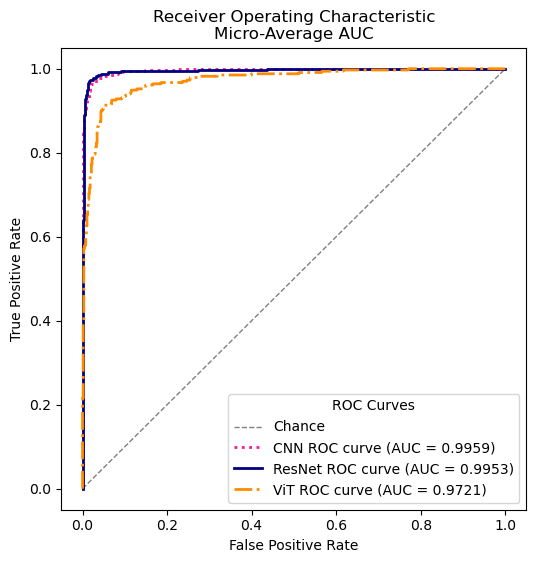

In [21]:
# Receiver Operating Characteristic Curve -  Micro-Average AUC
roc(type='micro', idx_cnn=2, idx_res=6, idx_vit=9)

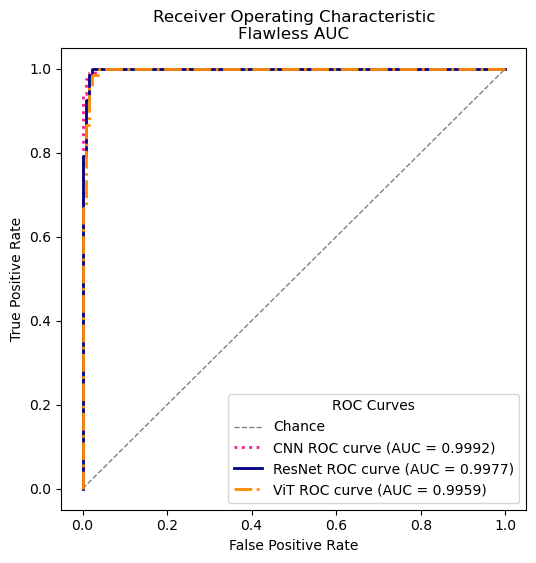

In [22]:
# Receiver Operating Characteristic Curve -  Flawless AUC
roc(type=0, idx_cnn=6, idx_res=0, idx_vit=4)

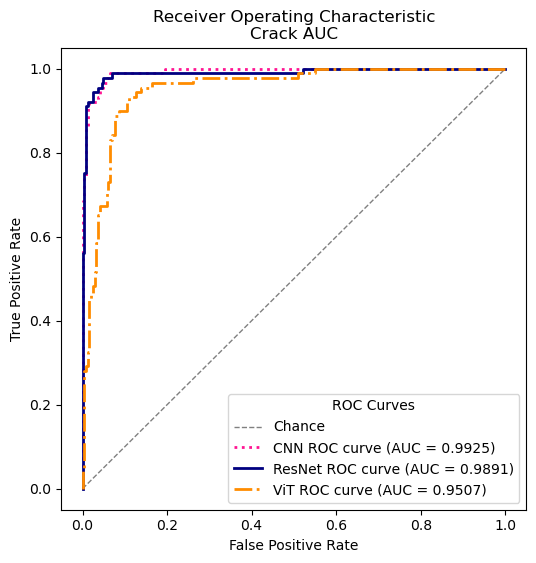

In [23]:
# Receiver Operating Characteristic Curve -  Crack AUC
roc(type=1, idx_cnn=2, idx_res=6, idx_vit=9)

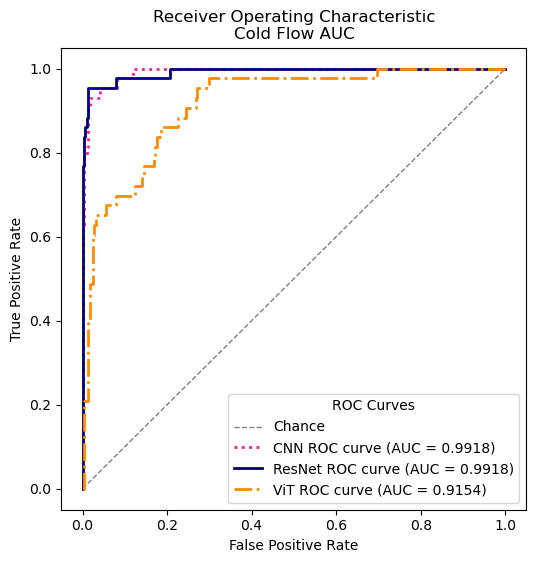

In [24]:
# Receiver Operating Characteristic Curve -  Cold Flow AUC
roc(type=2, idx_cnn=2, idx_res=9, idx_vit=5)

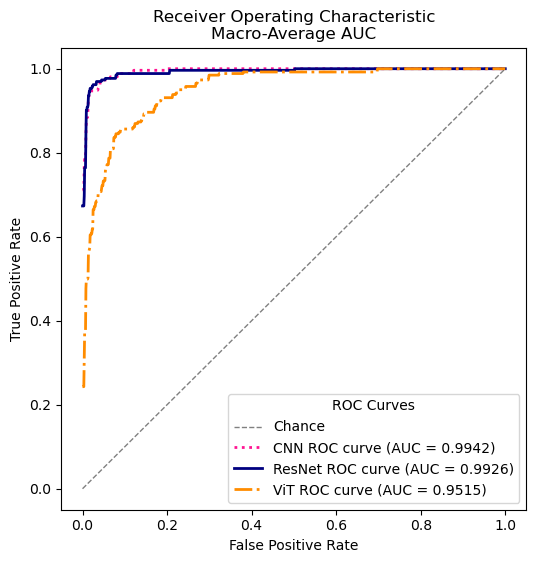

In [25]:
# Receiver Operating Characteristic Curve -  Macro-Average AUC
roc(type='macro', idx_cnn=2, idx_res=2, idx_vit=5)

# Metrics

In [1]:
import pickle
import numpy as np
from sklearn import metrics
import statistics
from scipy.stats import mode, ttest_rel

In [2]:
with open('C:/Users/101194208/Desktop/Die-Cast Ensemble/Data/data_oversample_usingViT.pkl', 'rb') as file:
    loaded_data = pickle.load(file)
X_train, X_val, X_test = loaded_data['var1'], loaded_data['var2'], loaded_data['var3']
y_train, y_val, y_test = loaded_data['var4'], loaded_data['var5'], loaded_data['var6']

with open('C:/Users/101194208/Desktop/Die-Cast Ensemble/Data/cnn.pkl', 'rb') as file:
    loaded_data = pickle.load(file)
cnn_prob, cnn_auc, cnn_fpr, cnn_tpr = loaded_data['var1'], loaded_data['var2'], loaded_data['var3'], loaded_data['var4']

with open('C:/Users/101194208/Desktop/Die-Cast Ensemble/Data/resnet.pkl', 'rb') as file:
    loaded_data = pickle.load(file)
res_prob, res_auc, res_fpr, res_tpr = loaded_data['var1'], loaded_data['var2'], loaded_data['var3'], loaded_data['var4']

with open('C:/Users/101194208/Desktop/Die-Cast Ensemble/Data/vit.pkl', 'rb') as file:
    loaded_data = pickle.load(file)
vit_prob, vit_auc, vit_fpr, vit_tpr = loaded_data['var1'], loaded_data['var2'], loaded_data['var3'], loaded_data['var4']

In [26]:
def m(y_true, y_prob, num_runs=10, model='CNN'):
    '''
    1. Calculate the metrics for each run and save
    2. Present the range of metrics and means
    '''
    accuracy = []
    precision = []
    recall = []
    f1 = []
    for i in range(num_runs):
        a = metrics.accuracy_score(y_true, np.argmax(y_prob[i], axis=1))
        p = metrics.precision_score(y_true, np.argmax(y_prob[i], axis=1), average="macro", zero_division=0.0)
        r = metrics.recall_score(y_true, np.argmax(y_prob[i], axis=1), average="macro", zero_division=0.0)
        f = metrics.f1_score(y_true, np.argmax(y_prob[i], axis=1), average="macro", zero_division=0.0)
        accuracy.append(a)
        precision.append(p)
        recall.append(r)
        f1.append(f)

    accuracy_max = max(accuracy); accuracy_min = min(accuracy); accuracy_mean = statistics.mean(accuracy)
    precision_max = max(precision); precision_min = min(precision); precision_mean = statistics.mean(precision)
    recall_max = max(recall); recall_min = min(recall); recall_mean = statistics.mean(recall)
    f1_max = max(f1); f1_min = min(f1); f1_mean = statistics.mean(f1)
    print(f"Model: {model}")
    print(f"Accuracy: ({accuracy_min:.4f}, {accuracy_max:.4f}), mean - {accuracy_mean:.4f}.")
    print(f"Precision: ({precision_min:.4f}, {precision_max:.4f}), mean - {precision_mean:.4f}.")
    print(f"Recall: ({recall_min:.4f}, {recall_max:.4f}), mean - {recall_mean:.4f}.")
    print(f"F1: ({f1_min:.4f}, {f1_max:.4f}), mean - {f1_mean:.4f}.")

In [27]:
m(y_test, cnn_prob, model='CNN')

Model: CNN
Accuracy: (0.9581, 0.9731), mean - 0.9665.
Precision: (0.9382, 0.9624), mean - 0.9528.
Recall: (0.9256, 0.9543), mean - 0.9435.
F1: (0.9317, 0.9582), mean - 0.9480.


In [28]:
m(y_test, res_prob, model='ResNet')

Model: ResNet
Accuracy: (0.9611, 0.9701), mean - 0.9692.
Precision: (0.9343, 0.9509), mean - 0.9492.
Recall: (0.9454, 0.9545), mean - 0.9536.
F1: (0.9384, 0.9519), mean - 0.9506.


In [38]:
m(y_test, vit_prob, model='ViT')

Model: ViT
Accuracy: (0.8503, 0.9042), mean - 0.8784.
Precision: (0.7421, 0.8468), mean - 0.7918.
Recall: (0.7395, 0.8118), mean - 0.7788.
F1: (0.7449, 0.8178), mean - 0.7824.


#### Hard Voting

In [8]:
# Calculate the prediction of Ensemble
num_runs=10
ensemble_pred = []
for i in range(num_runs):
    cnn = np.array(np.argmax(cnn_prob[i], axis=1))
    res = np.array(np.argmax(res_prob[i], axis=1))
    vit = np.array(np.argmax(vit_prob[i], axis=1))
    stacked_preds = np.vstack([cnn, res, vit])
    hard_voting_preds = mode(stacked_preds, axis=0).mode
    ensemble_pred.append(hard_voting_preds)

In [9]:
# Calculate the metrics for Ensemble
accuracy = []
precision = []
recall = []
f1 = []
for i in range(num_runs):
    a = metrics.accuracy_score(y_test, ensemble_pred[i])
    p = metrics.precision_score(y_test, ensemble_pred[i], average="macro", zero_division=0.0)
    r = metrics.recall_score(y_test, ensemble_pred[i], average="macro", zero_division=0.0)
    f = metrics.f1_score(y_test, ensemble_pred[i], average="macro", zero_division=0.0)
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    f1.append(f)

accuracy_max = max(accuracy); accuracy_min = min(accuracy); accuracy_mean = statistics.mean(accuracy)
precision_max = max(precision); precision_min = min(precision); precision_mean = statistics.mean(precision)
recall_max = max(recall); recall_min = min(recall); recall_mean = statistics.mean(recall)
f1_max = max(f1); f1_min = min(f1); f1_mean = statistics.mean(f1)
print(f"Model: Ensemble (Hard Voting)")
print(f"Accuracy: ({accuracy_min:.4f}, {accuracy_max:.4f}), mean - {accuracy_mean:.4f}.")
print(f"Precision: ({precision_min:.4f}, {precision_max:.4f}), mean - {precision_mean:.4f}.")
print(f"Recall: ({recall_min:.4f}, {recall_max:.4f}), mean - {recall_mean:.4f}.")
print(f"F1: ({f1_min:.4f}, {f1_max:.4f}), mean - {f1_mean:.4f}.")

Model: Ensemble (Hard Voting)
Accuracy: (0.9641, 0.9760), mean - 0.9707.
Precision: (0.9518, 0.9646), mean - 0.9577.
Recall: (0.9350, 0.9620), mean - 0.9505.
F1: (0.9432, 0.9631), mean - 0.9539.


#### Soft Voting

In [12]:
# Calculate the prediction of Ensemble
num_runs=10
ensemble_pred = []
for i in range(num_runs):
    cnn = cnn_prob[i]
    res = res_prob[i]
    vit = vit_prob[i]
    avg = np.mean([cnn, res, vit], axis=0)
    soft_voting_preds = np.array(np.argmax(avg, axis=1))
    ensemble_pred.append(soft_voting_preds)

In [13]:
# Calculate the metrics for Ensemble
accuracy = []
precision = []
recall = []
f1 = []
for i in range(num_runs):
    a = metrics.accuracy_score(y_test, ensemble_pred[i])
    p = metrics.precision_score(y_test, ensemble_pred[i], average="macro", zero_division=0.0)
    r = metrics.recall_score(y_test, ensemble_pred[i], average="macro", zero_division=0.0)
    f = metrics.f1_score(y_test, ensemble_pred[i], average="macro", zero_division=0.0)
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    f1.append(f)

accuracy_max = max(accuracy); accuracy_min = min(accuracy); accuracy_mean = statistics.mean(accuracy)
precision_max = max(precision); precision_min = min(precision); precision_mean = statistics.mean(precision)
recall_max = max(recall); recall_min = min(recall); recall_mean = statistics.mean(recall)
f1_max = max(f1); f1_min = min(f1); f1_mean = statistics.mean(f1)
print(f"Model: Ensemble (Soft Voting)")
print(f"Accuracy: ({accuracy_min:.4f}, {accuracy_max:.4f}), mean - {accuracy_mean:.4f}.")
print(f"Precision: ({precision_min:.4f}, {precision_max:.4f}), mean - {precision_mean:.4f}.")
print(f"Recall: ({recall_min:.4f}, {recall_max:.4f}), mean - {recall_mean:.4f}.")
print(f"F1: ({f1_min:.4f}, {f1_max:.4f}), mean - {f1_mean:.4f}.")

Model: Ensemble (Soft Voting)
Accuracy: (0.9671, 0.9760), mean - 0.9710.
Precision: (0.9518, 0.9646), mean - 0.9582.
Recall: (0.9388, 0.9620), mean - 0.9511.
F1: (0.9451, 0.9631), mean - 0.9545.


## T-test
#### Hard Voting

In [14]:
def tt(y_ture, y_prob, ensemble_pred):
    accuracy1 = []
    accuracy2 = []
    for i in range(10):
        a1 = metrics.accuracy_score(y_ture, np.argmax(y_prob[i], axis=1))
        a2 = metrics.accuracy_score(y_ture, ensemble_pred[i])
        accuracy1.append(a1)
        accuracy2.append(a2)
    t_statistic, p_value = ttest_rel(accuracy1, accuracy2)
    return format(p_value, '.6f')

In [15]:
tt(y_test, cnn_prob, ensemble_pred)

'0.000136'

In [16]:
tt(y_test, res_prob, ensemble_pred)

'0.322121'

In [17]:
tt(y_test, vit_prob, ensemble_pred)

'0.000000'

#### Soft Voting

In [14]:
def tt(y_ture, y_prob, ensemble_pred):
    accuracy1 = []
    accuracy2 = []
    for i in range(10):
        a1 = metrics.accuracy_score(y_ture, np.argmax(y_prob[i], axis=1))
        a2 = metrics.accuracy_score(y_ture, ensemble_pred[i])
        accuracy1.append(a1)
        accuracy2.append(a2)
    t_statistic, p_value = ttest_rel(accuracy1, accuracy2)
    return format(p_value, '.6f')

In [15]:
tt(y_test, cnn_prob, ensemble_pred)

'0.001742'

In [16]:
tt(y_test, res_prob, ensemble_pred)

'0.193422'

In [17]:
tt(y_test, vit_prob, ensemble_pred)

'0.000000'